# JAGUAR HSC QSO Joint Fit

This notebook mirrors the galight HSC QSO workflow using the same public HSC QSO example source. It downloads/caches the FITS files under `data/`, loads the science image and explicit PSF, fits an unresolved AGN plus Sersic host, and inspects residuals.


In [1]:
from dataclasses import replace
from pathlib import Path
import sys
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
for src in (repo_root / "src", repo_root.parent / "grahspj" / "src"):
    if src.is_dir() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
import numpy as np
import matplotlib.pyplot as plt
from jaguar import (
    SceneComponentConfig,
    SedComponentConfig,
    SourceDetectionConfig,
    build_components_from_detections,
    build_detection_image,
    detect_sources,
    ImageFitConfig,
    initialize_sed_component_amplitudes_from_pixels,
    JointFitConfig,
    build_grahspj_config_from_image_bands,
    download_galight_hsc_example,
    fit,
    load_hsc_band,
)
from jaguar.plotting import plot_detection, plot_fit, plot_sed




/Users/colinburke/miniforge3/envs/sed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Public galight HSC QSO Example


In [2]:
image_fits, psf_fits = download_galight_hsc_example(repo_root / "data/galight_hsc")
base_band = load_hsc_band(
    image_fits,
    psf_fits,
    filter_name="subaru.suprime.i",
    target_ra_dec=(0.07452999800443649, 0.4368380010128021),
    radius=30,
)
base_band.image.shape, base_band.psf.shape, base_band.pixel_scale, base_band.zeropoint


((61, 61), (41, 43), 0.16799999999990148, np.float64(27.0))

## Build a Multi-band Example


In [3]:
# The public galight archive has one HSC band for this QSO. For a runnable
# multi-band joint demo, derive HSC-like g/r/i stamps from the real i-band
# image using different amplitudes and noise realizations. Filter effective
# wavelengths are resolved later by grahspj from its vendored filter curves.
rng = np.random.default_rng(12)
band_specs = {
    "subaru.suprime.g": {"agn_scale": 0.75, "host_scale": 0.45},
    "subaru.suprime.r": {"agn_scale": 0.90, "host_scale": 0.75},
    "subaru.suprime.i": {"agn_scale": 1.00, "host_scale": 1.00},
}
base_total = float(np.clip(np.sum(base_band.image), 1.0, np.inf))
base_agn = 0.35 * base_total
base_host = 0.65 * base_total
image_bands = []
for name, spec in band_specs.items():
    agn_flux = base_agn * spec["agn_scale"]
    host_flux = base_host * spec["host_scale"]
    total_scale = (agn_flux + host_flux) / (base_agn + base_host)
    noise = base_band.noise * np.sqrt(max(total_scale, 0.25))
    image = base_band.image * total_scale + rng.normal(0.0, noise)
    image_bands.append(
        replace(
            base_band,
            image=image,
            noise=noise,
            filter_name=name,
            effective_wavelength=None,
        )
    )
[(band.filter_name, band.image.shape, band.effective_wavelength, band.counts_per_mjy) for band in image_bands]


[('subaru.suprime.g', (61, 61), None, 17378.00828749376),
 ('subaru.suprime.r', (61, 61), None, 17378.00828749376),
 ('subaru.suprime.i', (61, 61), None, 17378.00828749376)]

## Detect Extra Scene Sources


In [4]:
detection_cfg = SourceDetectionConfig(
    threshold=5.0,
    npixels=5,
    target_exclusion_radius_pix=3.0,
    deblend=True,
    deblend_nlevels=64,
    deblend_contrast=1e-4,
    max_sources=20,
    extendedness_threshold=1.0,
)
detection_image = build_detection_image(image_bands, detection_cfg)
detections = detect_sources(image_bands, detection_cfg)
[(d.id, d.classification, round(d.x_offset_pix, 2), round(d.y_offset_pix, 2), round(d.extendedness, 2), round(d.snr, 1)) for d in detections]


[(4, 'galaxy', -0.59, 9.9, 0.74, 82.5),
 (1, 'galaxy', -6.84, -29.04, 0.63, 40.7),
 (2, 'galaxy', -29.83, 25.48, 0.73, 26.9)]

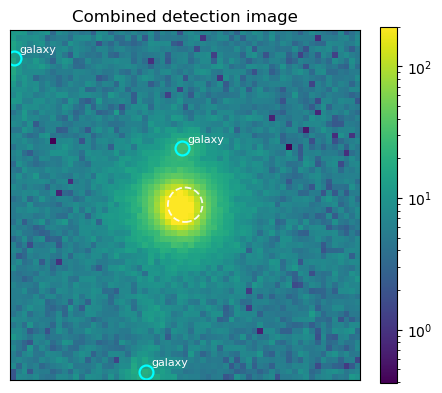

In [5]:
fig, ax = plot_detection(image_bands, detections, detection_cfg, detection_image=detection_image)
plt.show()



## Fit Multi-band AGN + Host


In [6]:
grahspj_cfg = build_grahspj_config_from_image_bands(
    image_bands,
    object_id="galight_hsc_qso",
    redshift=0.5,
    dsps_ssp_fn=str(repo_root.parent / "jaxqsofit/tempdata.h5"),
)
base_sed_components = [
    SedComponentConfig(name="agn", kind="agn", spatial="point", grahspj_config=grahspj_cfg),
    SedComponentConfig(name="host", kind="host", spatial="extended", grahspj_config=grahspj_cfg),
]
base_scene_components = [
    SceneComponentConfig(name="agn", sed_component="agn", kind="point", fixed_center_x_pix=0.0, fixed_center_y_pix=0.0),
    SceneComponentConfig(name="host", sed_component="host", kind="sersic", fixed_center_x_pix=0.0, fixed_center_y_pix=0.0, fixed_reff_arcsec=0.45, fixed_n_sersic=2.0),
]
extra_sed_components, extra_scene_components = build_components_from_detections(detections, grahspj_cfg, detection_cfg)
scene_components = [*base_scene_components, *extra_scene_components]
sed_components = initialize_sed_component_amplitudes_from_pixels(
    image_bands,
    [*base_sed_components, *extra_sed_components],
    scene_components,
    total_grahspj_config=grahspj_cfg,
)
cfg = JointFitConfig(
    image_bands=image_bands,
    image=ImageFitConfig(fit_background=True, background_default=0.0),
    sed_components=sed_components,
    scene_components=scene_components,
    grahspj_config=grahspj_cfg,
)
result = fit(cfg, fit_method="map_only", map_steps=1000, learning_rate=5.0e-3, progress_bar=False)
result.summary()



{'agn/log_agn_amp': 85.35255295883805,
 'agn/uv_slope': -1.0165728264624339,
 'agn/pl_slope': -3.109463820705859,
 'agn/pl_bend_loc': 593.9471160486762,
 'agn/pl_bend_width': 2.151547050785342,
 'agn/pl_cutoff': 69759.00316537567,
 'agn/fcov': 0.11930117308707354,
 'agn/si': -1.5400907408268902e-19,
 'agn/cool_lam': 16.282900929709054,
 'agn/cool_width': 0.4325029274691863,
 'agn/hot_lam': 1.855943244107016,
 'agn/hot_width': 0.4776256114731181,
 'agn/hot_fcov': 0.051069821611746946,
 'agn/lines_strength': 0.6861969256462133,
 'agn/line_width_kms': 2510.7657365335554,
 'agn/feii_norm': 14.445735104578837,
 'agn/ebv_agn': 0.08580562819580811,
 'host/log_stellar_mass': 10.460979824165973,
 'host/u_lgmcrit': 12.164996225007743,
 'host/u_lgy_at_mcrit': -9.999999999669468,
 'host/u_indx_lo': 1.8279692388944027,
 'host/u_indx_hi': -1.2343817610853869,
 'host/u_lg_qt': 0.9606172871705009,
 'host/u_qlglgdt': -0.3299655975160245,
 'host/u_lg_drop': -1.4464723002798294,
 'host/u_lg_rejuv': -0.49

## Inspect Image Components and Residuals


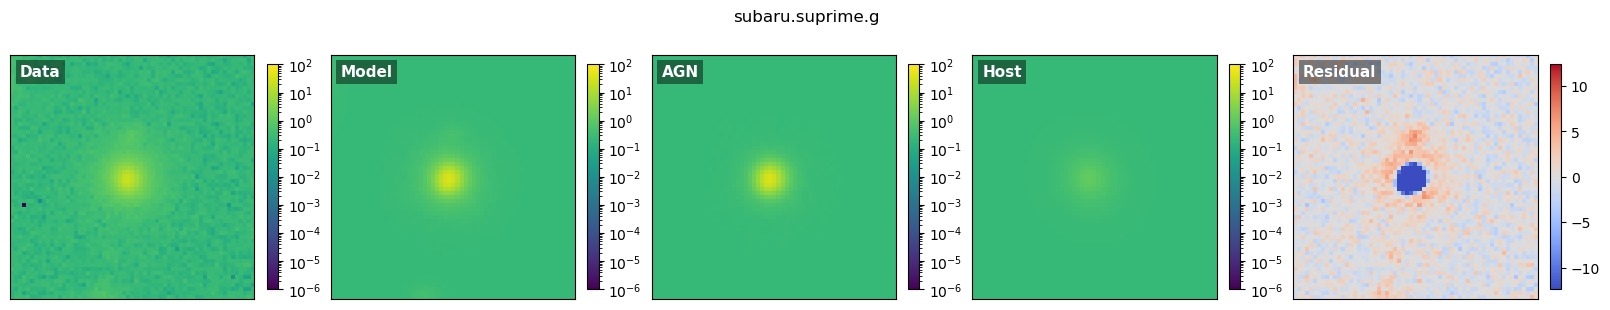

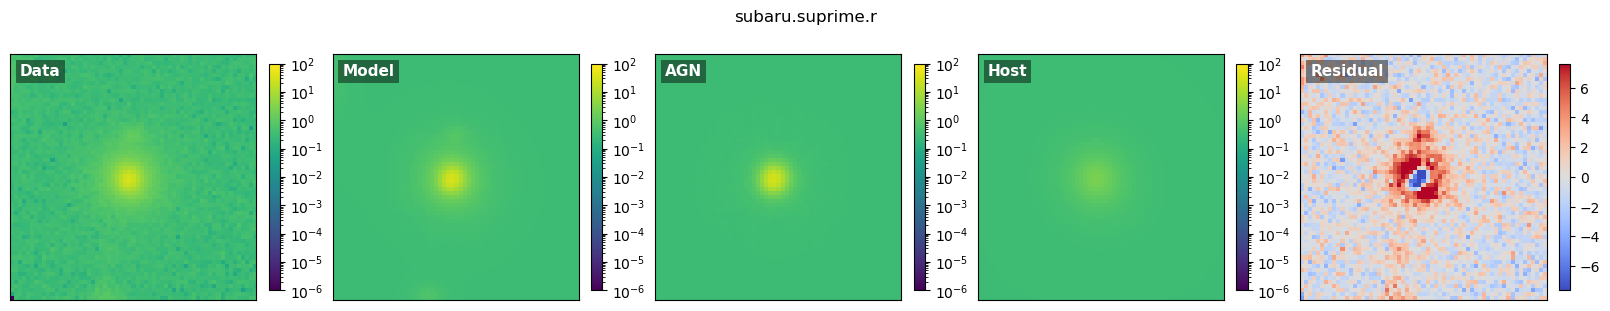

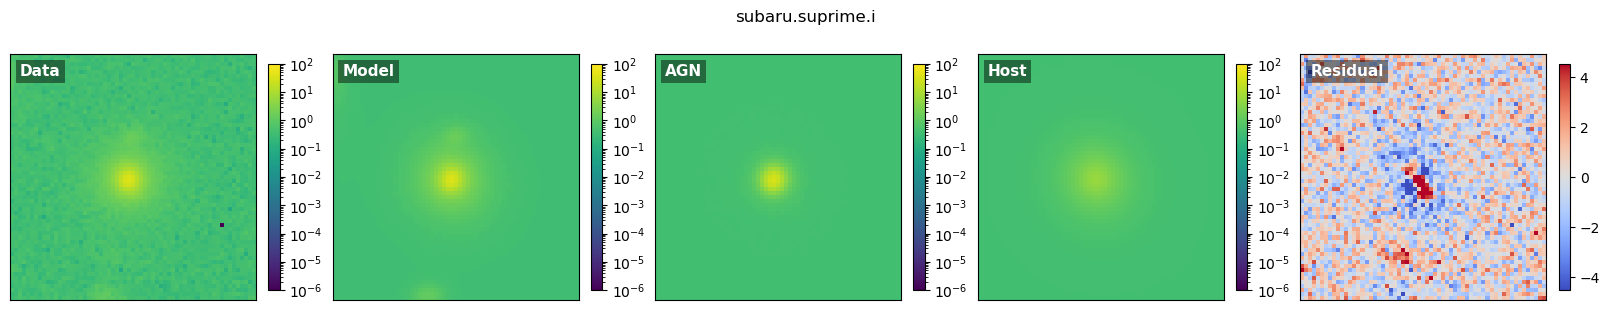

In [7]:
for band in image_bands:
    fig, axes = plot_fit(result, band.filter_name, shared_vmin=1e-6, shared_vmax=1e2)
    fig.suptitle(band.filter_name)
plt.show()


In [8]:
## Plot the Image-band SED


/Users/colinburke/research/grahspj/src/grahspj/plotting.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


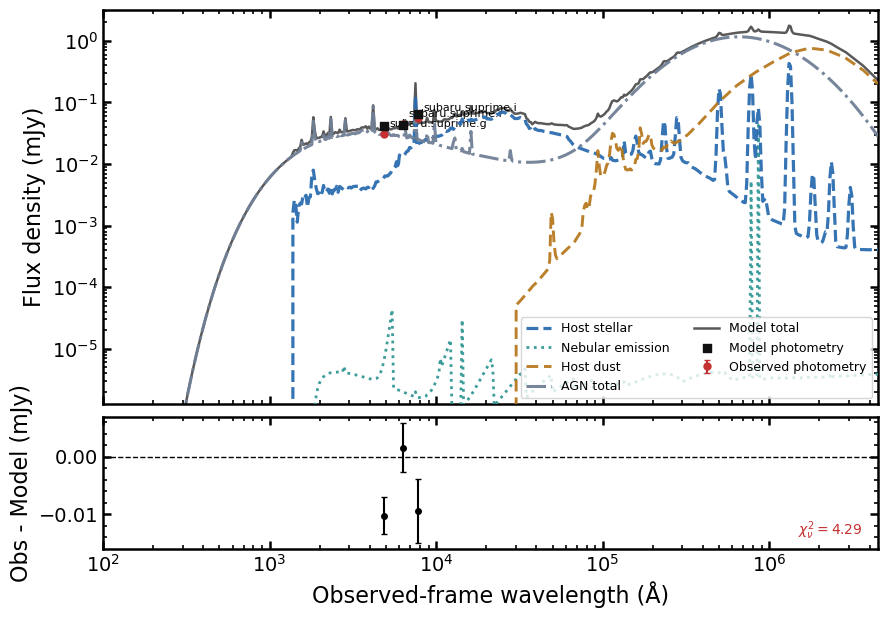

In [9]:
fig = plot_sed(result, show=True)

